In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

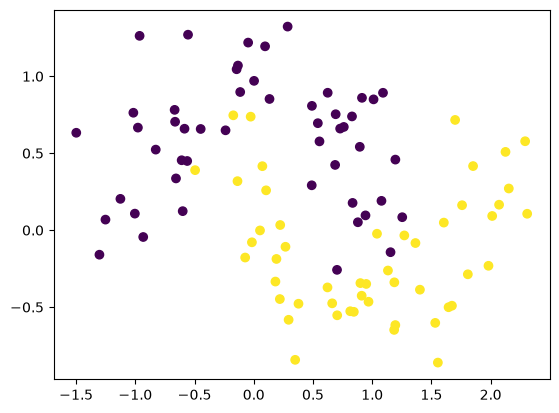

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

### Small weight Initialization

In [4]:
model=Sequential([
    Dense(units=128 , activation='sigmoid' , input_dim=2), 
    Dense(units=1 , activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.get_weights()

[array([[ 1.53902724e-01,  6.98764175e-02, -6.07075989e-02,
          1.93346545e-01, -1.81294039e-01,  6.54524714e-02,
          2.02159181e-01, -1.42687842e-01,  1.02215111e-02,
          5.61833233e-02, -1.77703217e-01, -2.30485201e-02,
          2.00240210e-01, -1.27435178e-02,  1.26597285e-03,
          1.14148423e-01, -2.06743822e-01, -1.32174373e-01,
          6.11916184e-03, -1.86293826e-01, -1.98659584e-01,
          1.49510428e-01,  1.78496465e-01, -1.02028832e-01,
          1.54479668e-01, -1.60062611e-01, -1.62047893e-02,
          2.69496292e-02,  2.86554247e-02, -1.28831059e-01,
         -1.24736018e-01,  2.10178509e-01, -1.67616874e-01,
         -2.42276192e-02, -1.00934148e-01, -1.62835389e-01,
          1.00174293e-01, -1.36488363e-01,  7.78971463e-02,
          6.46303743e-02, -1.96517333e-01,  2.73423344e-02,
         -7.12727457e-02, -4.86184210e-02,  1.95293739e-01,
         -3.85008901e-02,  1.35217607e-02, -1.05131514e-01,
         -1.62063748e-01,  9.27354246e-0

In [7]:
len(model.get_weights())

4

In [8]:
initial_weights = model.get_weights()

In [9]:
import numpy as np

initial_weights[0] = np.random.normal(scale=0.000000001, size=model.get_weights()[0].shape)
initial_weights[1] = np.random.normal(scale=0.000000001, size=model.get_weights()[1].shape)

initial_weights[2] = np.random.normal(scale=0.000000001, size=model.get_weights()[2].shape)

initial_weights[3] = np.random.normal(scale=0.000000001, size=model.get_weights()[3].shape)


In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[ 4.9671417e-10, -1.3826430e-10,  6.4768851e-10,  1.5230298e-09,
         -2.3415336e-10, -2.3413696e-10,  1.5792128e-09,  7.6743473e-10,
         -4.6947440e-10,  5.4256005e-10, -4.6341769e-10, -4.6572973e-10,
          2.4196228e-10, -1.9132802e-09, -1.7249179e-09, -5.6228755e-10,
         -1.0128312e-09,  3.1424732e-10, -9.0802410e-10, -1.4123037e-09,
          1.4656487e-09, -2.2577630e-10,  6.7528205e-11, -1.4247482e-09,
         -5.4438271e-10,  1.1092259e-10, -1.1509935e-09,  3.7569803e-10,
         -6.0063871e-10, -2.9169375e-10, -6.0170663e-10,  1.8522782e-09,
         -1.3497225e-11, -1.0577109e-09,  8.2254492e-10, -1.2208436e-09,
          2.0886359e-10, -1.9596702e-09, -1.3281860e-09,  1.9686124e-10,
          7.3846657e-10,  1.7136828e-10, -1.1564828e-10, -3.0110370e-10,
         -1.4785220e-09, -7.1984418e-10, -4.6063878e-10,  1.0571223e-09,
          3.4361830e-10, -1.7630402e-09,  3.2408398e-10, -3.8508227e-10,
         -6.7692202e-10,  6.1167627e-10,  1.0309995

In [12]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.4125 - loss: 0.7364 - val_accuracy: 0.3500 - val_loss: 0.7345
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5375 - loss: 0.6854 - val_accuracy: 0.6500 - val_loss: 0.6735
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4625 - loss: 0.7038 - val_accuracy: 0.6500 - val_loss: 0.6929
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4125 - loss: 0.6989 - val_accuracy: 0.3500 - val_loss: 0.7392
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5375 - loss: 0.6952 - val_accuracy: 0.3500 - val_loss: 0.7445
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5375 - loss: 0.6884 - val_accuracy: 0.3500 - val_loss: 0.7155
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5375 - loss: 0.6871 - val_accuracy: 0.3500 - val_loss: 0.7015
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5375 - loss: 0.6907 - val_accuracy: 0.3500 - val_loss: 0.7111

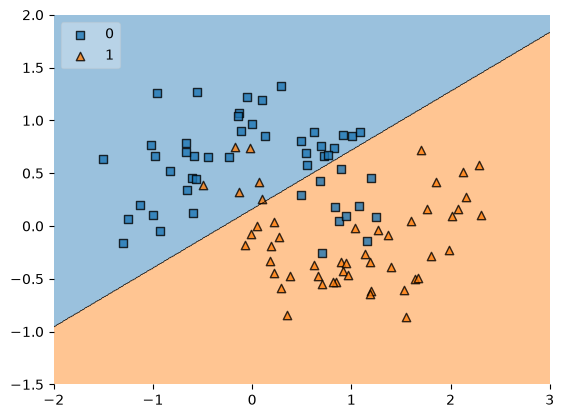

In [13]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

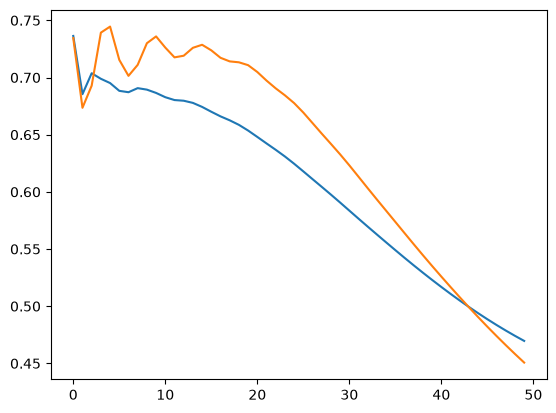

In [14]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [15]:
model.get_weights()

[array([[ 0.9187872 ,  0.9188781 ,  0.9188867 ,  0.9189438 ,  0.91890204,
          0.9187913 ,  0.91878134,  0.9188906 ,  0.9187569 ,  0.91894263,
          0.91890836,  0.9187972 ,  0.9187368 ,  0.91891295,  0.9188332 ,
          0.91890717,  0.91874415,  0.9187911 ,  0.9188701 ,  0.91887015,
          0.91880155,  0.91889274,  0.9187644 ,  0.9188333 ,  0.9188757 ,
          0.9188909 ,  0.9188958 ,  0.9187521 ,  0.9187456 ,  0.91891193,
          0.9188859 ,  0.9187864 ,  0.9189223 ,  0.9188757 ,  0.91890836,
          0.9188701 ,  0.9189484 ,  0.91893315,  0.9188165 ,  0.91890204,
          0.9189028 ,  0.9189142 ,  0.9187735 ,  0.91889507,  0.9189074 ,
          0.91873324,  0.9187591 ,  0.9187247 ,  0.9188169 ,  0.9188958 ,
          0.9189192 ,  0.9188701 ,  0.91892505,  0.918748  ,  0.91873723,
          0.91885746,  0.9188874 ,  0.91886854,  0.91872156,  0.91883755,
          0.9187562 ,  0.91890323,  0.9188873 ,  0.9187756 ,  0.9187942 ,
          0.91876477,  0.91885746,  0.